In [83]:
import sys
sys.path.insert(0,'../scripts')
from pycap_for_PESTPP_MOU import postprocess_MOU, plot_pareto, prep_for_viz, create_viz_app, plot_pareto_with_scenarios
from pathlib import Path
from ipywidgets import interact, fixed
import yaml
import matplotlib.pyplot as plt

# Read in one of the configuration files and postprocess it. 
### The `config_file` should be your `secnario_name` + `".yml"` as assigned in the `05_MOU_setup_run.ipynb` notebook. 

In [84]:
configurations = ['depletion_q_baseline_0.0_1.0_0.01', 'depletion_q_Tmin10per_0.0_1.0_0.01', 'depletion_q_Tplus10per_0.0_1.0_0.01']

config = configurations[1]  # Select the desired configuration
config_file = config + '.yml'

with open(Path('./configurations') / config_file,'r') as ifp:
    inpars = yaml.safe_load(ifp)
inpars

{'depletion_potential_threshold': 0.01,
 'objectives': 'depletion_q',
 'pump_lbound_fraction': 0.0,
 'pump_ubound_fraction': 1.0,
 'ref_q': 8.6,
 'run_path': '../pycap_runs/pycap_pest/run_depletion_q_Tmin10per_0.0_1.0_0.01',
 'scenario_name': 'depletion_q_Tmin10per_0.0_1.0_0.01'}

### Below, the `config_file` is processed, beginning the postprocessing

In [85]:
run_path = Path(inpars['run_path'])
run_name = inpars['scenario_name']
pareto_df = postprocess_MOU(run_name, run_path)

In [86]:
pareto_df

,generation,member,Depletion (cfs),Total Pumping (cfs),nsga2_front,nsga2_crowding_distance,spea2_unconstrained_fitness,spea2_constrained_fitness,is_feasible,feasible_distance
0,0,68,4.12620,36.303700,1,1.000000e+30,0.001695,0.001695,1,-999
1,0,152,4.52850,39.085358,1,1.000000e+30,0.004549,0.004549,1,-999
2,0,16,4.24440,38.467534,1,6.315720e-01,0.005091,0.005091,1,-999
3,0,130,4.44052,38.600100,1,5.063380e-01,0.007305,0.007305,1,-999
4,0,95,4.44810,38.900657,1,2.186970e-01,0.007305,0.007305,1,-999
...,...,...,...,...,...,...,...,...,...,...
9481,50,gen=50_member=8522_pso,2.01305,31.747440,1,8.794110e-03,1.004370,1.004370,1,-999
9482,50,gen=50_member=8459_pso,3.19929,35.424309,1,3.495590e-03,0.016662,0.016662,1,-999
9483,50,gen=50_member=8435_pso,3.22160,35.479340,1,5.405400e-03,0.016971,0.016971,1,-999
9484,50,gen=50_member=8472_pso,1.99550,31.655201,1,6.332380e-03,0.004836,0.004836,1,-999


### Next the evolution of the pareto frontier is plotted, over MOU iterations. Check out how the algorithm converges on a well-defined pareto tradeoff frontier

In [87]:
interact(plot_pareto,  currgen=(0,50,1), pareto_df=fixed(pareto_df));

interactive(children=(IntSlider(value=25, description='currgen', max=50), Output()), _dom_classes=('widget-int…

### Where do your scenarios line up? You can provide a list of scenarios that you ran in notebook #3 in the following function to plot a red "x" where each scenario plots up

### NOTE: This only works for the fish vs. receipts case!

In [88]:
dollars=False
# if 'dollar' in inpars['objectives']:
#     dollars = True
# if dollars:
#     plot_pareto_with_scenarios(pareto_df, scenarios=['LPR_Single_Run','LPR_Single_Run70','LPR_Single_Run90'])

### Finally, there is an interactive plot with the pareto frontier on the left and a map of corresponding "optimal" pumping rates on the right. 

### Note - if you get an error about ports being in conflict, change the `port=4242` argument to a different number than `4242`

In [89]:
pareto_df_final, dv_df =  prep_for_viz(pareto_df, 50, run_path, run_name, dollar_objective=dollars)
# app = create_viz_app(pareto_df_final, dv_df)
# app.run(port=4242)

### check out `pareto_df_final` and `dv_df`. What's in these datasets? What further analysis can you perform with this information?

In [90]:
dv_df.T.sample(10)

,well_1013,well_1302,well_1323,well_1486,well_1584,well_1589,well_1643,well_1683,well_1860,well_23610,...,well_93143,well_93349,well_93422,well_93423,well_93424,well_93469,well_93832,well_94302,well_94988,well_95068
gen=23_member=3878_pso,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
gen=50_member=8459_pso,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
gen=41_member=6977_pso,1.0,1.0,1.0,0.928356,0.106211,1.0,1.0,1.0,1.0,0.99677,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0
gen=50_member=8462_pso,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
gen=43_member=7394_pso,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
gen=30_member=5100_pso,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
gen=45_member=7626_pso,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
gen=28_member=4715_pso,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
gen=47_member=7971_pso,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0
gen=41_member=6886_pso,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [91]:
pareto_df_final.columns

Index(['generation', 'member', 'Depletion (cfs)', 'Total Pumping (cfs)',
       'nsga2_front', 'nsga2_crowding_distance', 'spea2_unconstrained_fitness',
       'spea2_constrained_fitness', 'is_feasible', 'feasible_distance'],
      dtype='object')

In [92]:
pareto_df_final.sample(10)

,generation,member,Depletion (cfs),Total Pumping (cfs),nsga2_front,nsga2_crowding_distance,spea2_unconstrained_fitness,spea2_constrained_fitness,is_feasible,feasible_distance
9332,50,gen=26_member=4423_pso,3.26519,35.565341,1,0.004796,0.016547,0.016547,1,-999
9279,50,gen=43_member=7348_pso,2.10246,32.166304,1,0.005940,0.004665,0.004665,1,-999
9224,50,gen=44_member=7506_pso,1.80049,30.743949,1,0.007760,0.004562,0.004562,1,-999
9192,50,gen=47_member=7926_pso,4.15447,37.297166,1,0.008845,0.006277,0.006277,1,-999
9156,50,gen=48_member=8156_pso,1.57884,29.522782,1,0.011737,0.002785,0.002785,1,-999
9179,50,gen=47_member=7970_pso,1.75247,30.570611,1,0.009395,0.003520,0.003520,1,-999
9317,50,gen=33_member=5629_pso,2.69006,34.212277,1,0.005088,0.008542,0.008542,1,-999
9264,50,gen=38_member=6474_pso,2.49902,33.622302,1,0.004786,0.009695,0.009695,1,-999
9215,50,gen=38_member=6459_pso,1.11823,25.920106,1,0.007937,0.002030,0.002030,1,-999
9391,50,gen=41_member=6926_pso,3.80951,36.651491,1,0.003275,0.016107,0.016107,1,-999


In [93]:
new_df = pareto_df_final.copy()
new_df.insert(2, "Streamflow (cfs)", 8.6 - new_df["Depletion (cfs)"])

In [94]:
new_df.columns

Index(['generation', 'member', 'Streamflow (cfs)', 'Depletion (cfs)',
       'Total Pumping (cfs)', 'nsga2_front', 'nsga2_crowding_distance',
       'spea2_unconstrained_fitness', 'spea2_constrained_fitness',
       'is_feasible', 'feasible_distance'],
      dtype='object')

In [95]:
# If we want to, we can save out the pareto tradeoff objectives results to a file. 
# Just change the name below and it will be a new copy!
new_df[['member', 'Total Pumping (cfs)', 'Streamflow (cfs)', 'Depletion (cfs)']].to_csv(f'{config}_tradeoff.csv')

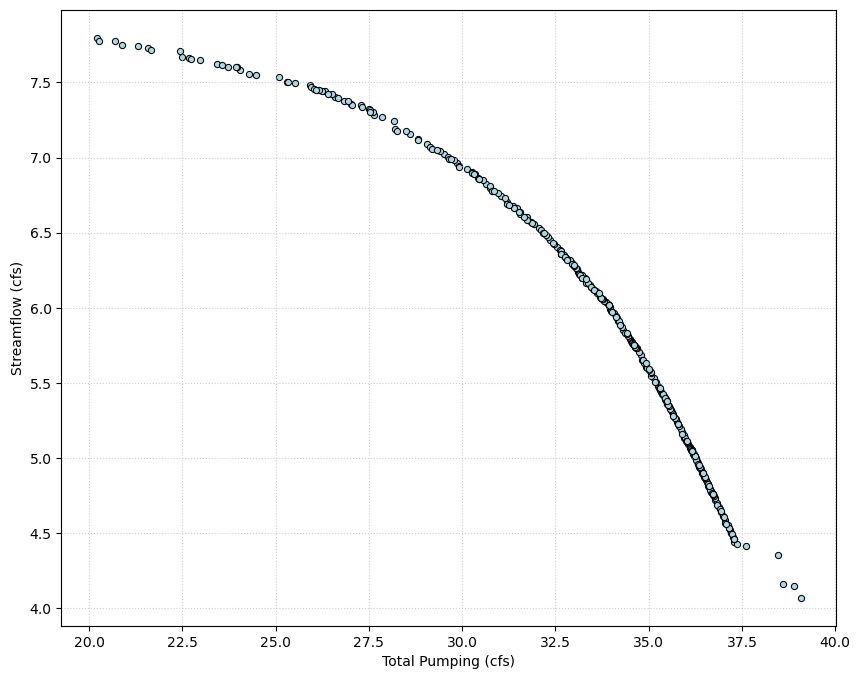

In [96]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(new_df["Total Pumping (cfs)"], new_df["Streamflow (cfs)"], marker="o", s=20, c="lightblue", edgecolors="black", linewidths=0.75)
ax.set_xlabel("Total Pumping (cfs)")
ax.set_ylabel("Streamflow (cfs)")
ax.grid(linestyle=":", alpha=0.6)
plt.show()